In [1]:
from benchmark.examples.gaussian.approximators.config import TrainingConfig
from benchmark.examples.gaussian.approximators.indirect_NPE import train_one
from benchmark.examples.gaussian.approximators.simulators import get_simulator

config = TrainingConfig(
    num_dims=20,
    num_obs=100,
    summary_dim=20,
    epochs=256,
    batch_size=64,
    num_batches=128,
    learning_rate=1e-4,
    seed=2025,
)

INFO:bayesflow:Using backend 'tensorflow'


In [2]:

workflow, history = train_one(
    model="m1",
    config=config,
    save=True,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.



Training m1: D=20, N=100, S=20

Epoch 1/256
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - CouplingFlow/loss: 27.0974 - DeepSet/loss: 0.3271 - loss: 27.4245 - val_CouplingFlow/loss: 25.0909 - val_DeepSet/loss: 0.3552 - val_loss: 25.4461
Epoch 2/256
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - CouplingFlow/loss: 22.5988 - DeepSet/loss: 0.4045 - loss: 23.0034 - val_CouplingFlow/loss: 20.2176 - val_DeepSet/loss: 0.4621 - val_loss: 20.6797
Epoch 3/256
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - CouplingFlow/loss: 17.7673 - DeepSet/loss: 0.4660 - loss: 18.2333 - val_CouplingFlow/loss: 14.7133 - val_DeepSet/loss: 0.5016 - val_loss: 15.2150
Epoch 4/256
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - CouplingFlow/loss: 13.1179 - DeepSet/loss: 0.4979 - loss: 13.6158 - val_CouplingFlow/loss: 11.1012 - val_DeepSet/loss: 0.5141 - val_loss: 11.6153
Epoch 5/256
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - CouplingFlow/loss: 10.4427 - DeepSet/loss: 0.4995 - loss: 10.9422 - val_CouplingFlow/loss: 8.4236 - va

INFO:bayesflow:Training completed in 28.49 minutes.


Saved network: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/networks/m1_s_20d_100n.keras
Saved history: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/networks/history/m1_s_20d_100n.json


In [3]:
print(history.history.keys())

dict_keys(['CouplingFlow/loss', 'DeepSet/loss', 'loss', 'val_CouplingFlow/loss', 'val_DeepSet/loss', 'val_loss'])


In [4]:
print(history.history)

{'CouplingFlow/loss': [27.097423553466797, 22.598840713500977, 17.767322540283203, 13.117902755737305, 10.442697525024414, 8.14804458618164, 6.397582530975342, 4.968829154968262, 3.8582193851470947, 2.948237657546997, 2.125654697418213, 1.3806700706481934, 0.9537205696105957, 0.3989309072494507, 0.14783978462219238, -0.12280167639255524, -0.3740586042404175, -0.6072428226470947, -0.8612017631530762, -0.9724543690681458, -1.1934466361999512, -1.2400281429290771, -1.5283476114273071, -1.5781984329223633, -1.7512222528457642, -1.840914249420166, -1.955049753189087, -2.0687999725341797, -2.249988555908203, -2.430807113647461, -2.604950189590454, -2.831927537918091, -2.9175260066986084, -3.1166465282440186, -3.384669303894043, -3.5530152320861816, -3.7542264461517334, -3.8187854290008545, -3.947068214416504, -4.082550525665283, -4.159226894378662, -4.198953628540039, -4.323073863983154, -4.372420787811279, -4.412211894989014, -4.520666599273682, -4.5201239585876465, -4.544562339782715, -4.6

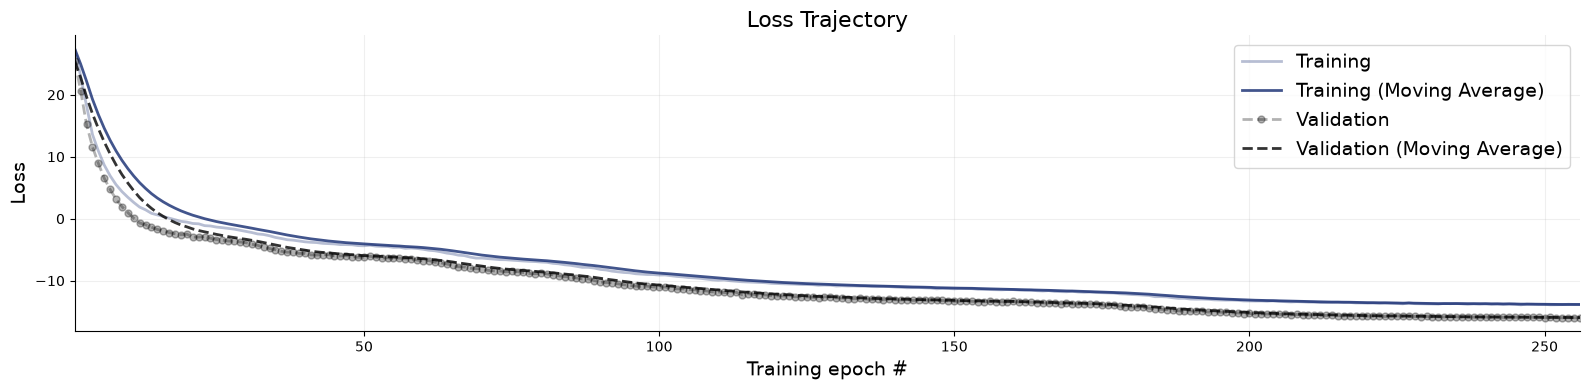

In [5]:
import bayesflow as bf
f=bf.diagnostics.plots.loss(history)

In [6]:
import keras
import bayesflow as bf

from benchmark.examples.gaussian.config import NETWORK_DIR

path = NETWORK_DIR / "m1_s_20d_100n.keras"

approximator = keras.saving.load_model(path)

print(type(approximator))

<class 'bayesflow.approximators.continuous_approximator.ContinuousApproximator'>


In [7]:
# simulator
import numpy as np
RNG=np.random.default_rng(2025)
def prior(mu=0, sigma=1):
    mu = RNG.normal(loc=mu, scale=sigma, size=20)
    return dict(mu=mu)
def likelihood(mu):
    x =RNG.normal(loc=mu, scale=1, size=(100, 20))
    return dict(x=x)
simulator=bf.make_simulator([prior,likelihood])

In [8]:
# Generate test datasets and get posterior samples and perform diagnostics
num_samples = 1000 #number of posterior samples
val_sims = simulator.sample(200) # validation data
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)
post_draws.keys()


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 1.09 seconds.


dict_keys(['mu'])

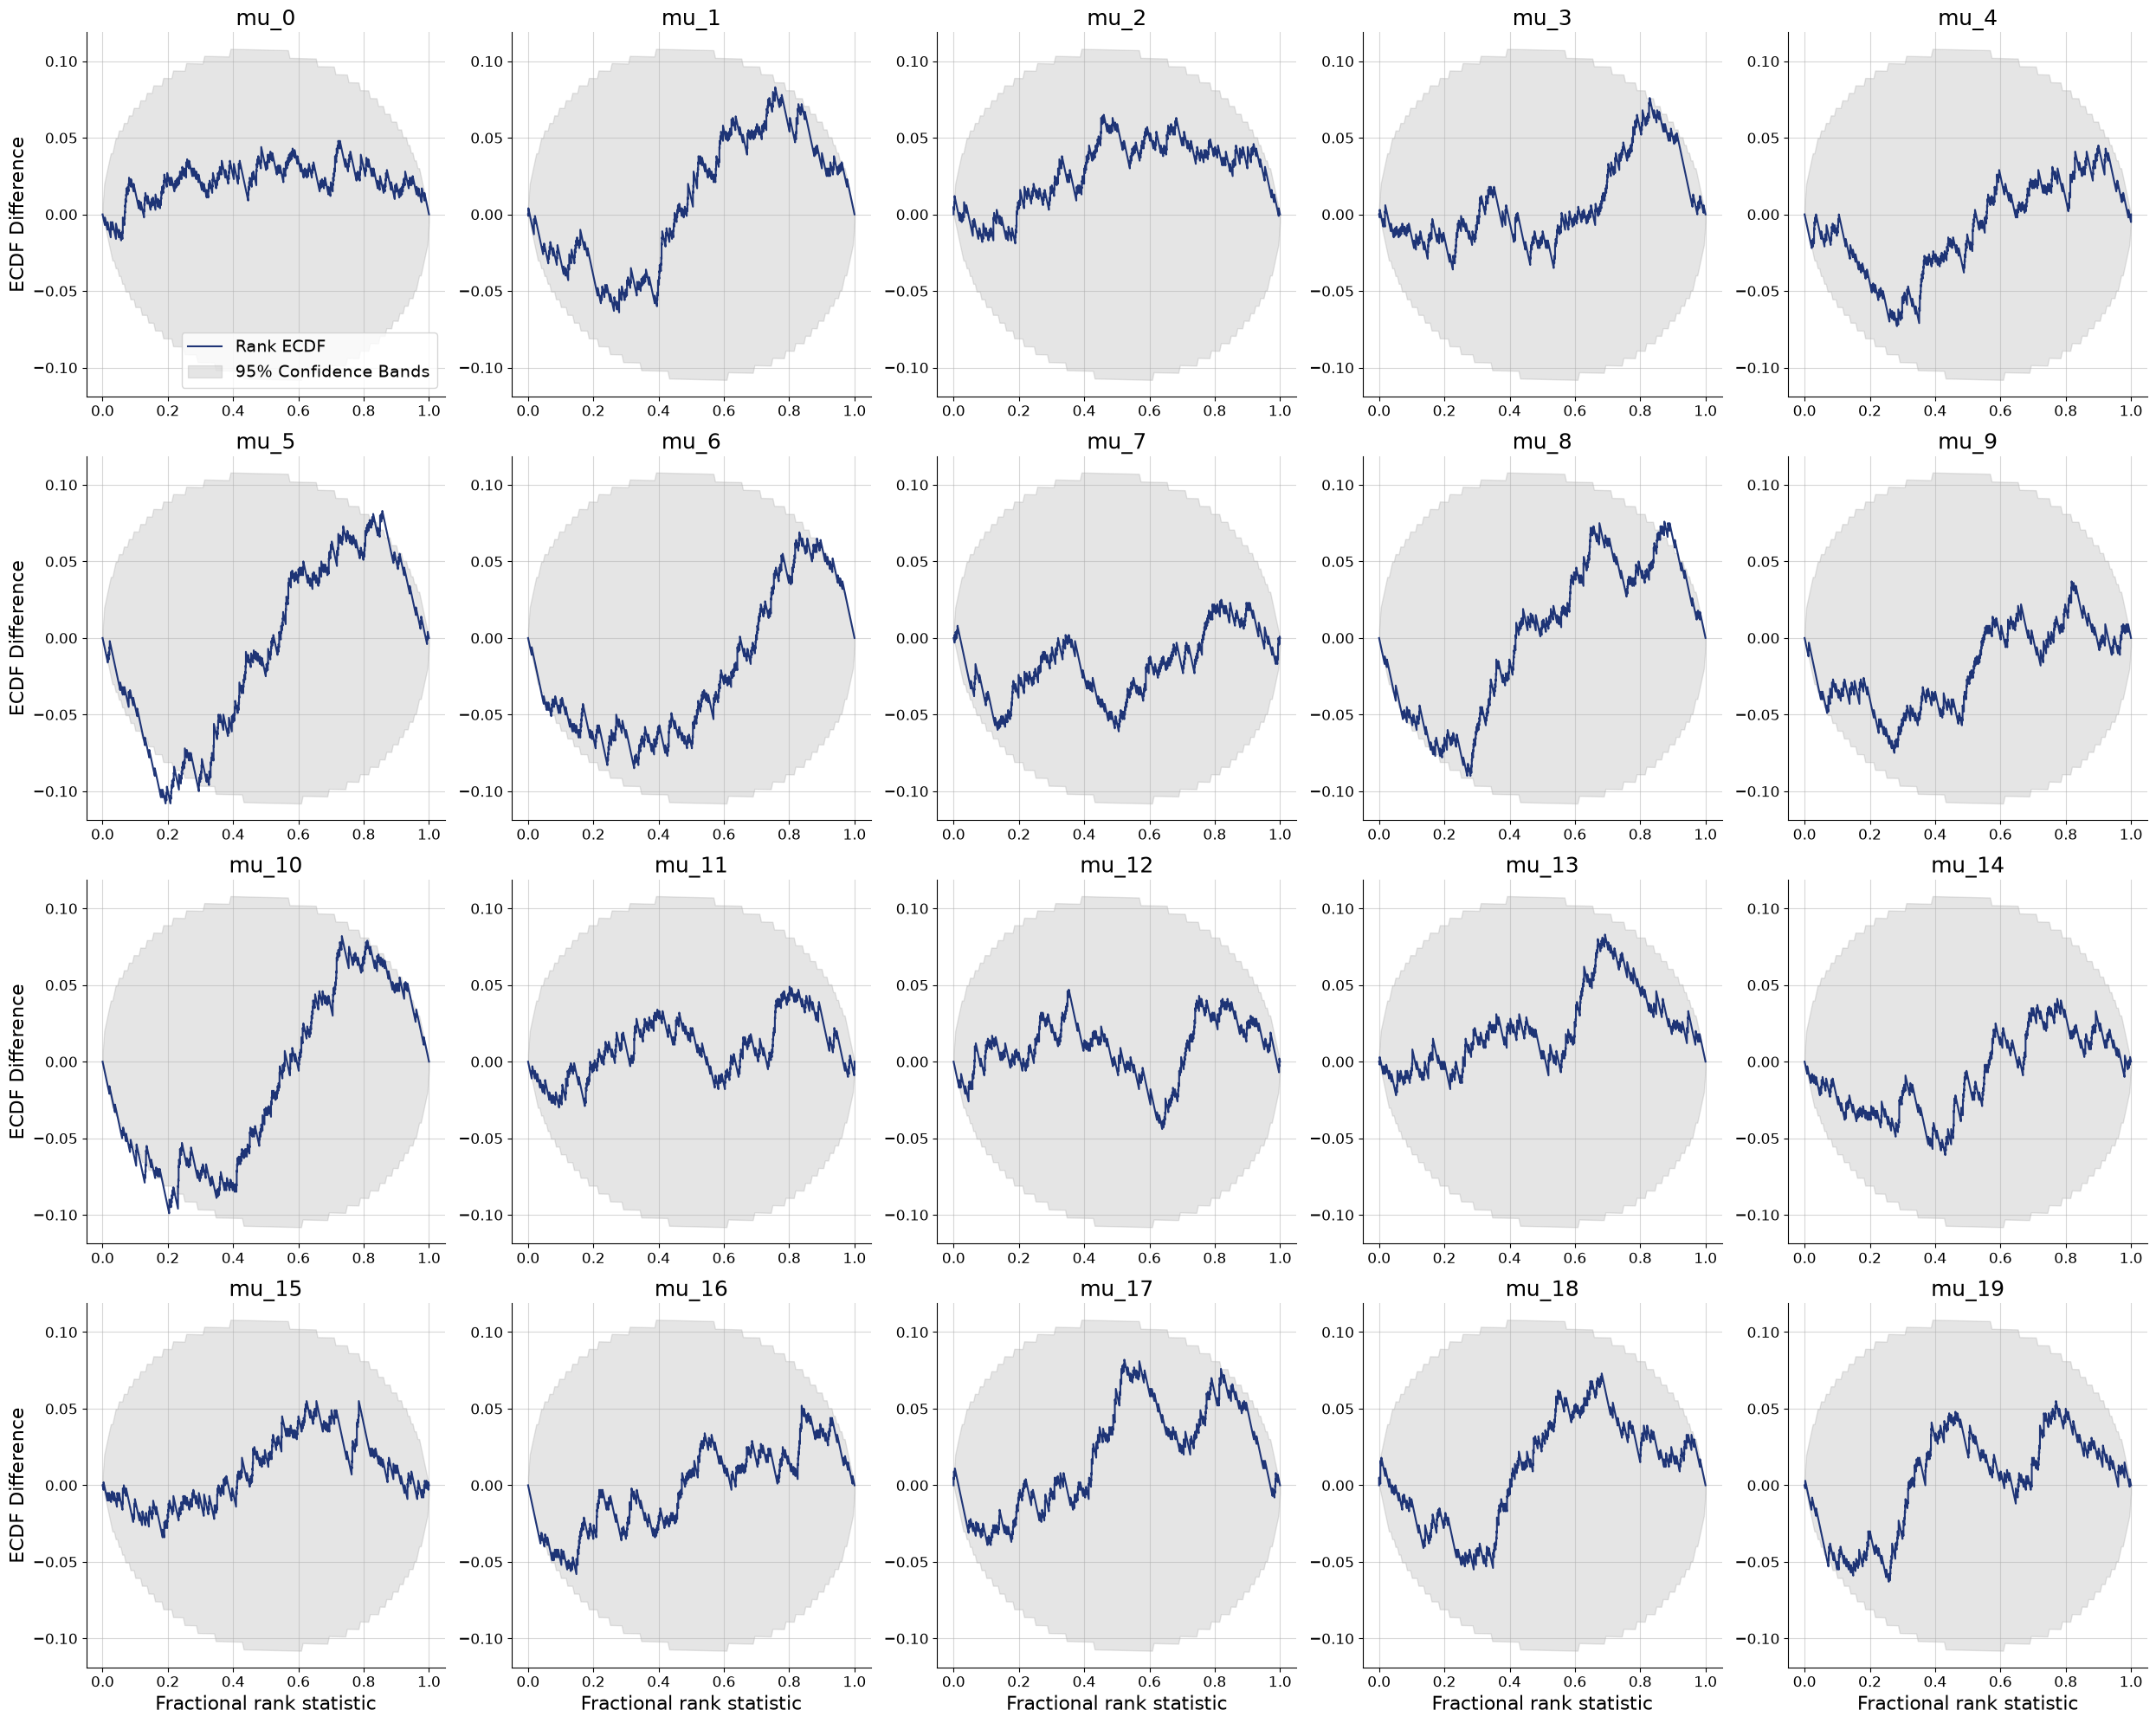

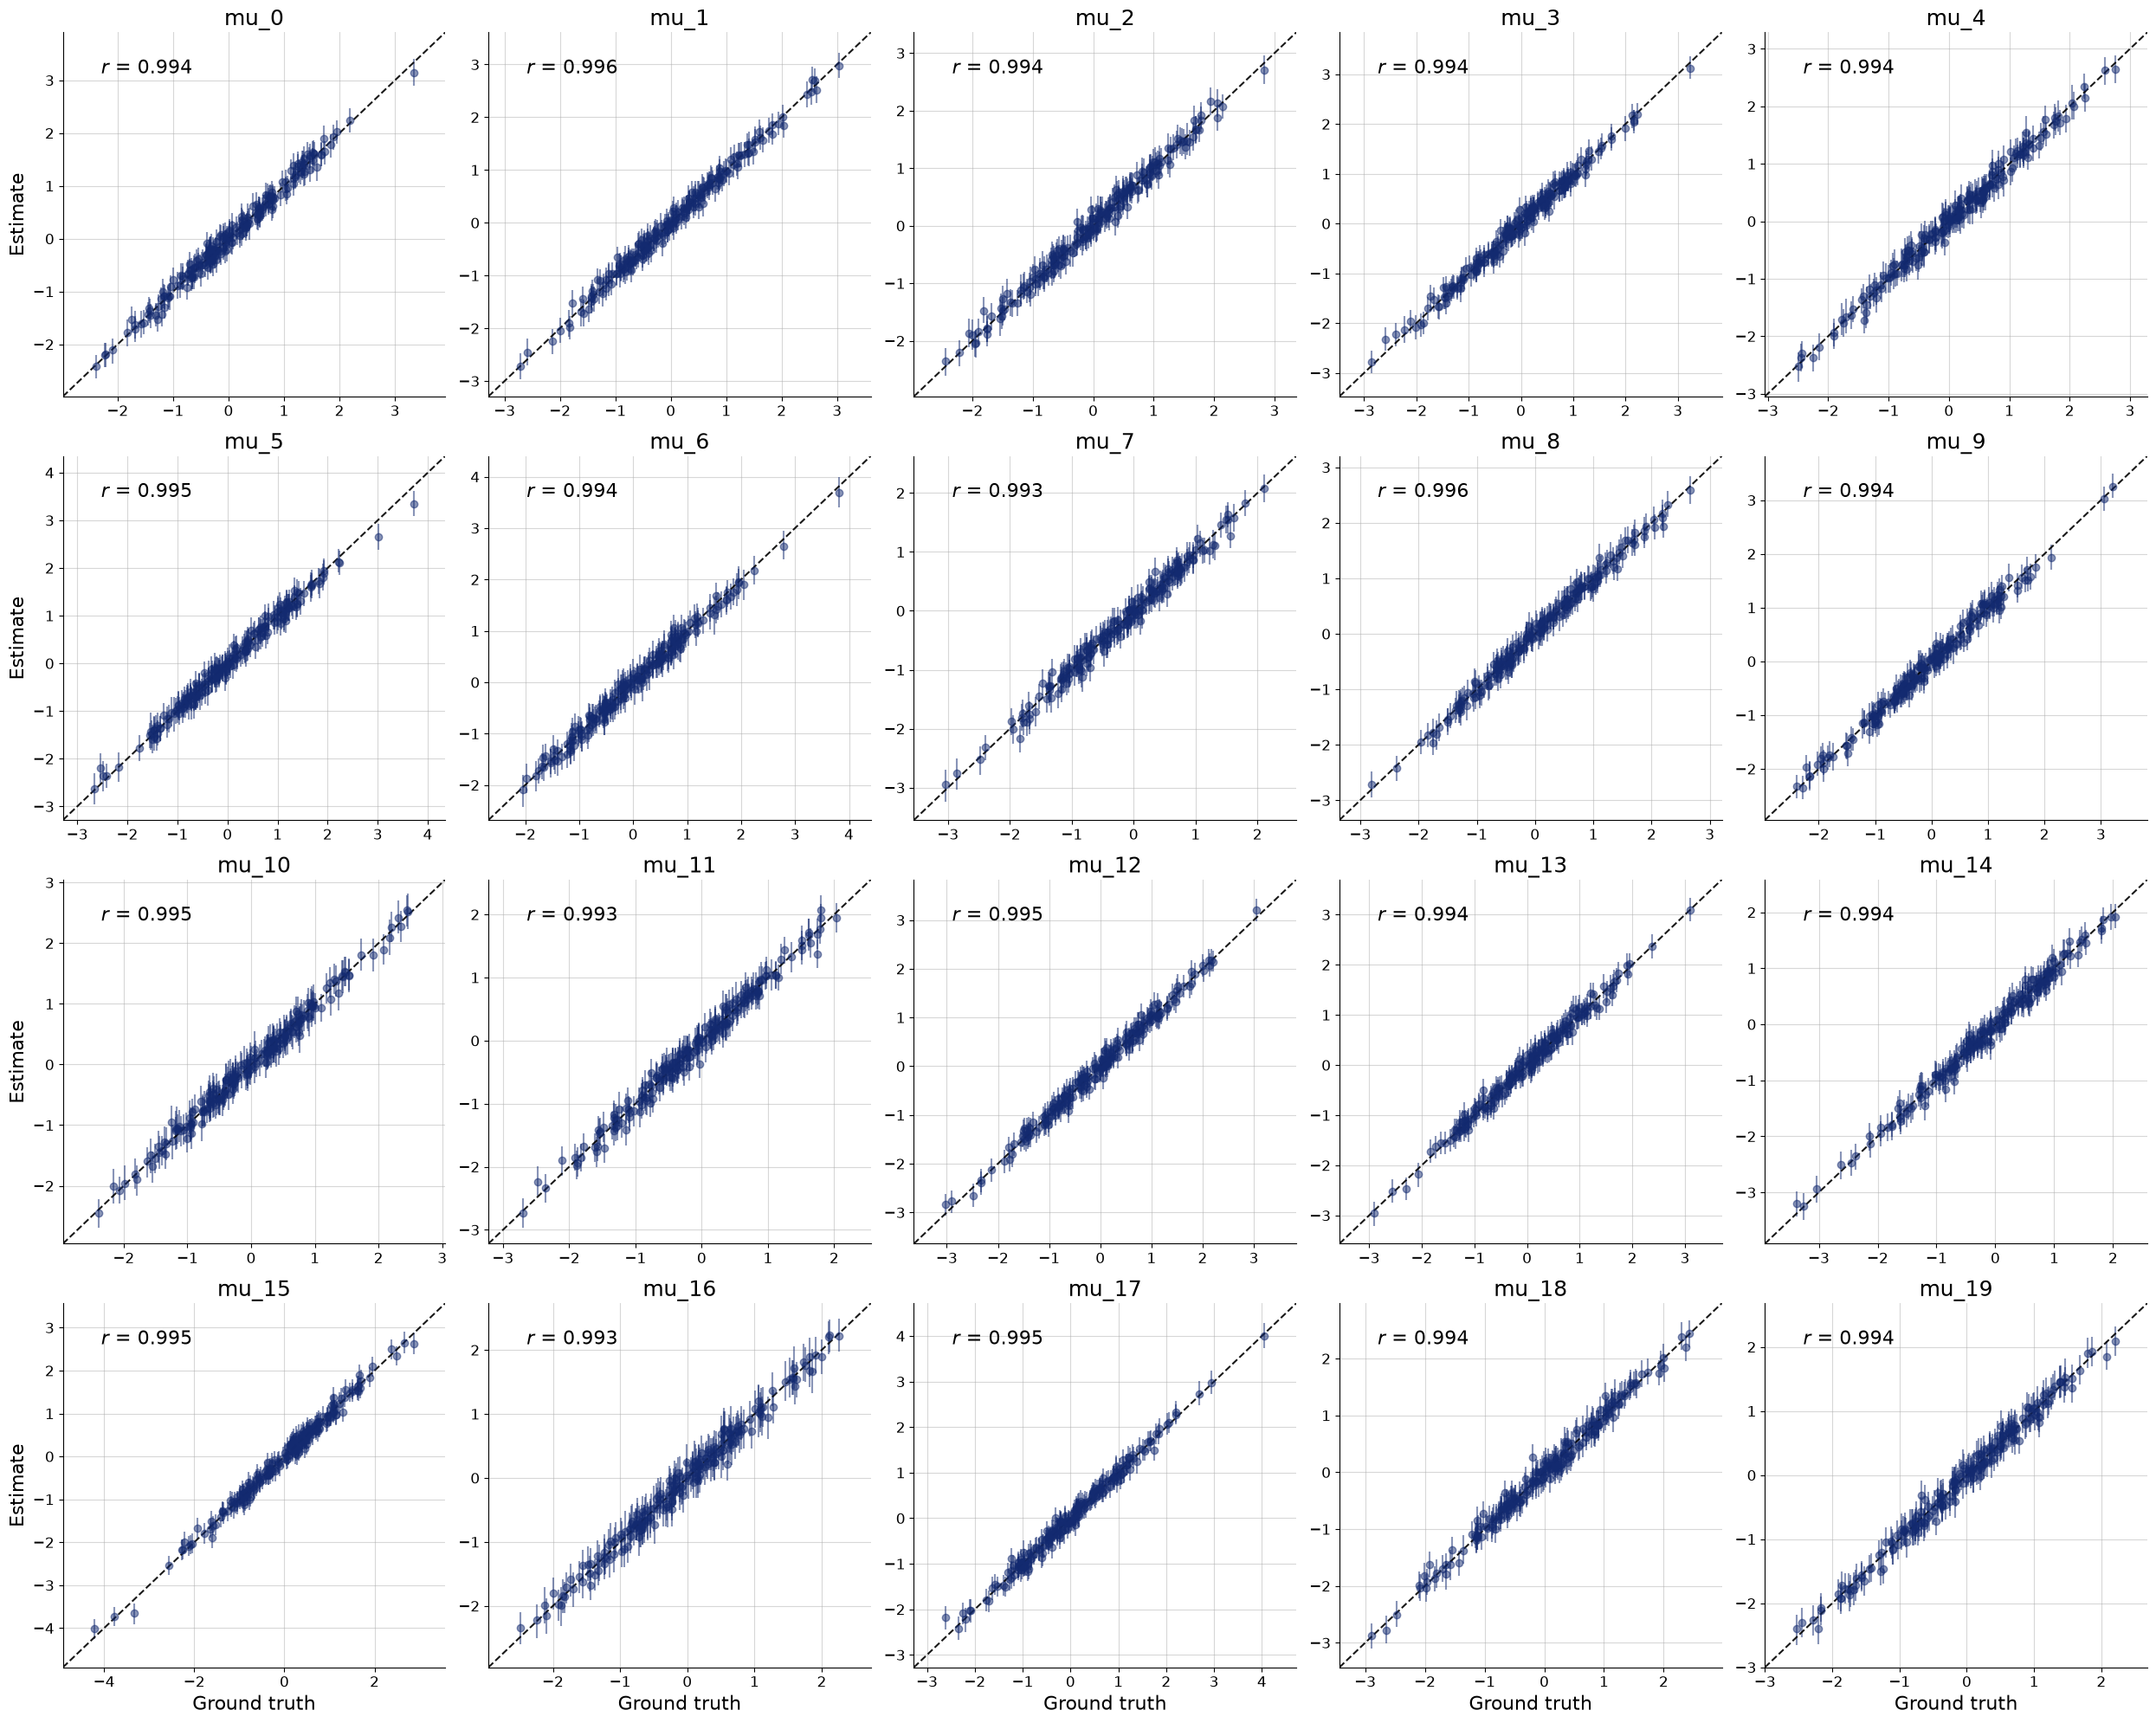

In [9]:
# f1 = bf.diagnostics.plots.calibration_histogram(post_draws, val_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims,difference=True)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)